In [1]:
import pennylane as qml 
import torch
import pennylane.numpy as np 
import pandas as pd

In [2]:
data = pd.read_csv('AirPassengers_scaled.csv')
data['x'] = range(1, len(data) + 1)

In [3]:
Air_y = torch.from_numpy(data['Passengers_scaled'].values).view(-1,1).to(torch.float)
Air_y_q = torch.pi * Air_y 
Air_x = torch.from_numpy(data['x'].values).view(-1,1).to(torch.float)

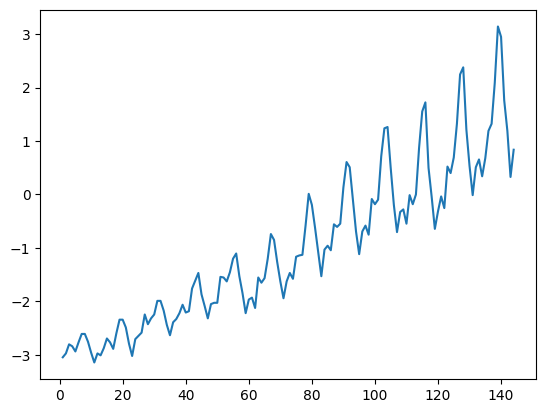

In [4]:
import matplotlib.pyplot as plt
plt.plot(Air_x, Air_y_q)

In [5]:
import torch
import torch.nn as nn
from torch.optim import Optimizer
from typing import Callable, Optional
import matplotlib.pyplot as plt
from IPython.display import clear_output

# Mean squared error loss with type annotations and better numerical stability
def mse(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
    return torch.mean(torch.square(y_true - y_pred))

# Training loop with type annotations and structure
def train(
    X: torch.Tensor,
    Y: torch.Tensor,
    x_true: torch.Tensor,
    y_true: torch.Tensor,
    model: nn.Module,
    optimizer: Optimizer,
    iterations: int,
    lossfn: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
    callback: Optional[Callable[[nn.Module, torch.Tensor], None]] = None
) -> None:
    """
    Trains the given model on input X and target Y using the specified optimizer and loss function.
    Optionally, a callback function can be provided for monitoring progress.
    """
    for i in range(iterations):
        optimizer.zero_grad()
        prediction = model(X)
        loss = lossfn(Y, prediction)
        loss.backward()
        optimizer.step()

        if callback is not None:
            callback(model, loss, x_true, y_true)

# Loss tracking list
losses: list[float] = []

# Callback function for visualizing training progress
def callback(model: nn.Module, loss: torch.Tensor, x, y) -> None:
    losses.append(loss.item())
    
    #x = torch.linspace(0, 10, 500).view(-1, 1)
    prediction = model(x).detach()

    clear_output(wait=True)

    # Plot predictions vs. true sine function
    plt.figure(figsize=(6, 2.5))
    plt.plot(x[:, 0], y[:, 0], label="Exact solution", color="tab:grey", alpha=0.6)
    plt.plot(x[:, 0], prediction[:, 0], label="Model prediction", color="tab:green")
    plt.title(f"Training Step {len(losses)}")
    plt.legend()
    plt.show()

    # Plot loss curve
    plt.figure(figsize=(6, 2.5))
    plt.title("Loss Function Over Time")
    plt.plot(losses)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.show()

In [6]:
import pennylane as qml

n_qubits = 4
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev)
def qnode(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    #qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

n_layers = 5

#weight_shapes = {"weights": (n_layers, n_qubits)}
weight_shapes = {"weights": (n_layers, n_qubits, 3)}

qlayer = qml.qnn.TorchLayer(qnode, weight_shapes)

In [7]:
class QN(torch.nn.Module):
    '''Classical -> Quantum -> Classical'''

    def __init__(self, n_input: int, n_output: int, quanutm_layer):
        super().__init__()

        self.layers = torch.nn.Sequential(
            torch.nn.Linear(n_input, n_qubits),
            quanutm_layer,
            torch.nn.Linear(n_qubits, n_output)
        )
        

    def forward(self, x):
        return  self.layers(x)

In [8]:
reg_qmodel = QN(1, 1, qlayer)
print(reg_qmodel)

QN(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=4, bias=True)
    (1): <Quantum Torch Layer: func=qnode>
    (2): Linear(in_features=4, out_features=1, bias=True)
  )
)


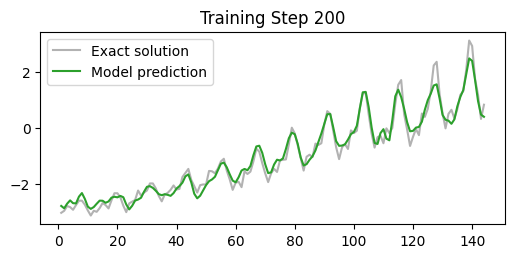

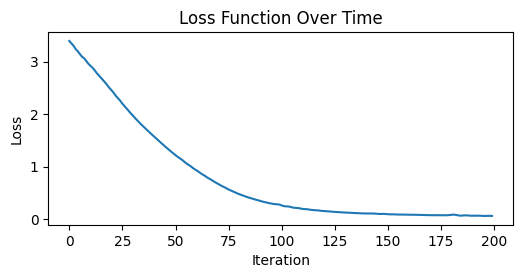

In [9]:
from IPython.display import clear_output 

learning_rate=1e-2
optimiser = torch.optim.Adam(reg_qmodel.parameters(), lr=learning_rate)

train(Air_x, Air_y_q, Air_x, Air_y_q, reg_qmodel, optimiser, 200, mse, callback)

In [10]:
predictions = reg_qmodel(Air_x)

In [12]:

mse(Air_y_q, predictions)

tensor(0.0619, grad_fn=<MeanBackward0>)

In [19]:
import torch

def r2_score(y_true, y_pred):
    """Oblicza współczynnik determinacji R²"""
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return r2.item()

def mae(y_true, y_pred):
    return torch.mean(torch.abs(y_true - y_pred)).item()

def rmse(y_true, y_pred):
    return torch.sqrt(torch.mean((y_true - y_pred)**2)).item()

def smape(y_true, y_pred, eps=1e-8):
    return torch.mean(2 * torch.abs(y_pred - y_true) /
                      (torch.abs(y_true) + torch.abs(y_pred) + eps)) * 100


In [14]:
y_true = Air_y_q
y_pred = predictions

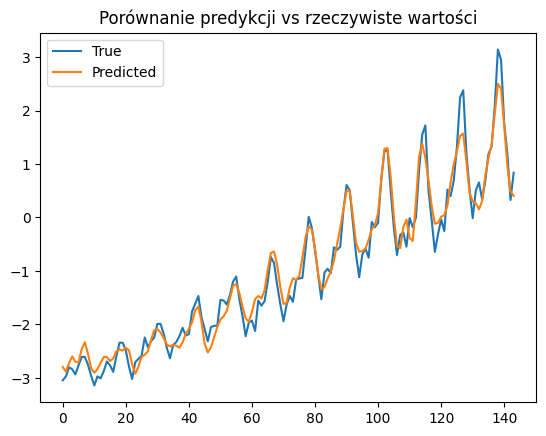

In [15]:
import matplotlib.pyplot as plt

plt.plot(y_true.detach().numpy(), label='True')
plt.plot(y_pred.detach().numpy(), label='Predicted')
plt.legend()
plt.title('Porównanie predykcji vs rzeczywiste wartości')
plt.show()

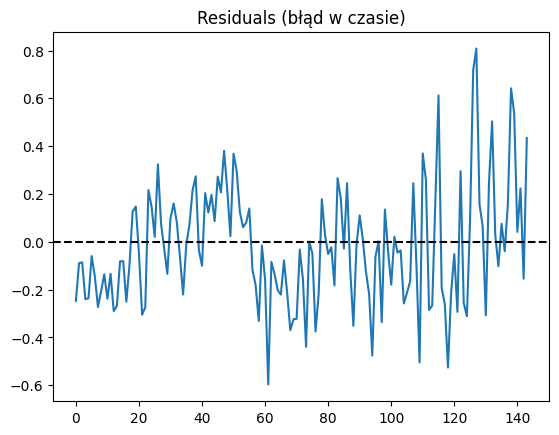

In [16]:
error = (y_true - y_pred).detach().numpy()
plt.plot(error)
plt.title("Residuals (błąd w czasie)")
plt.axhline(0, color='black', linestyle='--')
plt.show()

In [21]:
print(f"R²  ={r2_score(y_true, y_pred)}\nMSE  ={mse(y_true, y_pred)}" )
print(f"mae  ={mae(y_true, y_pred)}\nRMSE ={rmse(y_true, y_pred)}" )
print(f"smape ={smape(y_true, y_pred)}")

R²  =0.9705862402915955
MSE  =0.061850447207689285
mae  =0.19715073704719543
RMSE =0.24869750440120697
smape =33.06394958496094
